# [[5,1,3]] QEC fidelity testing

Standalone QEC benchmark separated from the broadcasting protocol notebook.
Builds an encode/delay/decode circuit, runs it on a noise-free Aer simulator
for the ideal reference, then submits to a real IBM backend and saves the
results under `results/qec513/`.

In [1]:
# Setup and IBM backend connection
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from broadcasting.qec_513 import five_qubit_decode_gate, decode_qec_513
from time import sleep
from datetime import datetime
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(linewidth=200, precision=3, suppress=True)

service = QiskitRuntimeService(name="mprest1")

QEC_RESULTS_DIR = Path("results/qec513")
QEC_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

management.get:WARNING:2026-05-17 14:29:40,510: Loading saved account: mprest1


State: Ry(2.4315) Rz(2.7576) |0⟩
Circuit depth (unbound): 36
Total qubits: 9  (5 data + 4 ancilla)


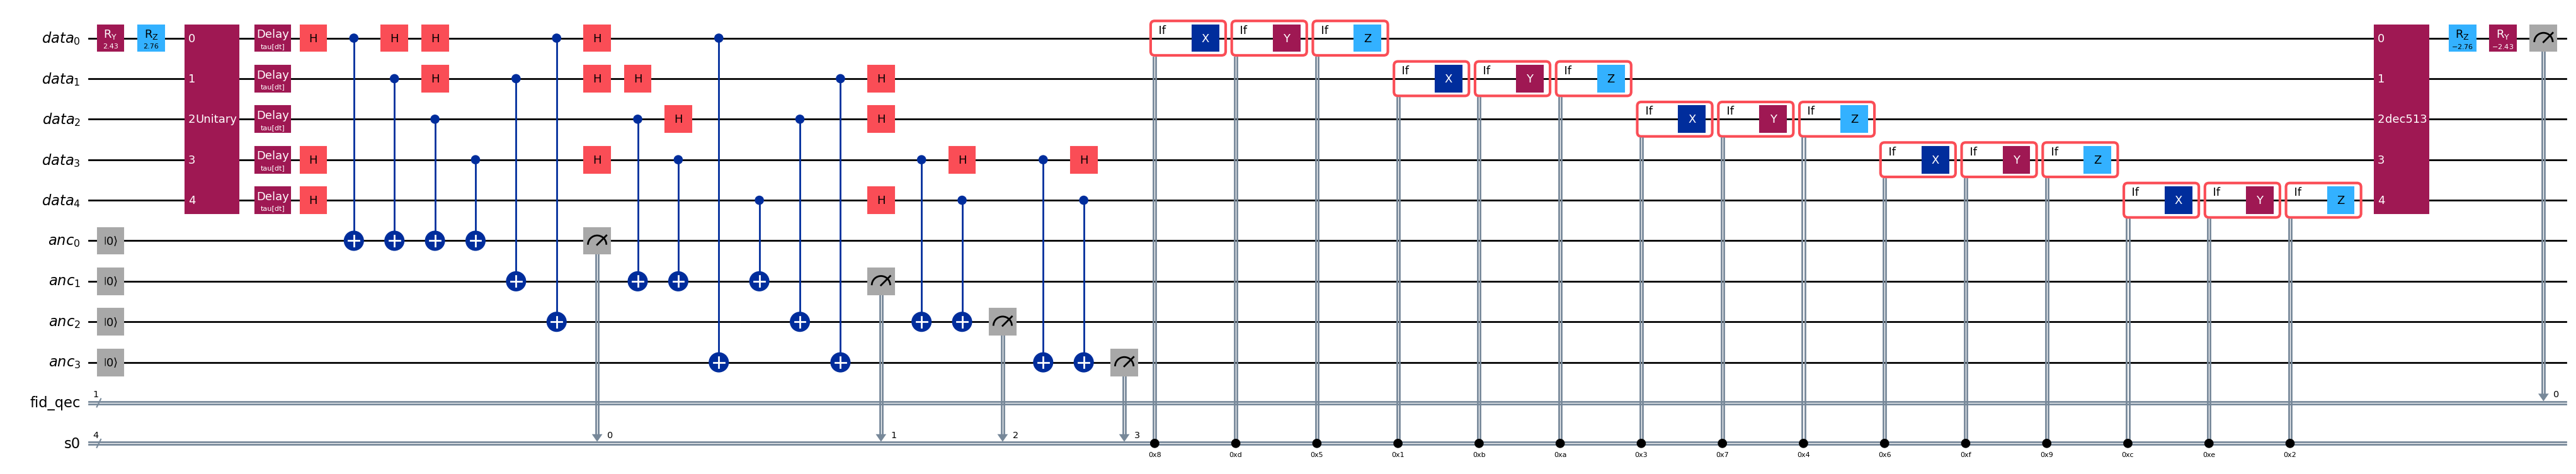

In [3]:
# QEC [[5,1,3]] fidelity benchmark circuit
# Prepares a random phase state, encodes it into the [[5,1,3]] code, applies
# a parametric time delay, decodes (with syndrome correction), and measures
# the fidelity of the recovered qubit.

seed = 42
rng = np.random.default_rng(seed)

# --- Parameters ---
theta_qec = float(rng.uniform(0, np.pi))      # polar angle for |ψ⟩ = Ry(θ)|0⟩
phi_qec   = float(rng.uniform(0, 2 * np.pi))  # azimuthal angle (Rz(φ) applied after Ry)
tau_qec   = Parameter("tau")                   # delay duration in dt units
shots_qec = 8192

# --- Build the encode gate = adjoint of decode gate ---
decode_gate = five_qubit_decode_gate()
encode_gate = decode_gate.adjoint()   # maps |00000⟩ → |0_L⟩, |00001⟩ → |1_L⟩

# --- Registers ---
data = QuantumRegister(5, "data")         # [[5,1,3]] physical block
anc  = QuantumRegister(4, "anc")          # ancilla for syndrome measurement
fid  = ClassicalRegister(1, "fid_qec")    # fidelity readout

qc_qec = QuantumCircuit(data, anc, fid)

# 1. Prepare random phase state on data[0]
qc_qec.ry(theta_qec, data[0])
qc_qec.rz(phi_qec,   data[0])

# 2. Encode into [[5,1,3]] block
qc_qec.append(encode_gate, data[:])

# 3. Parametric delay on every physical qubit in the block
for q in data:
    qc_qec.delay(tau_qec, q)

# 4. Decode (syndrome extraction, classical feedforward, decode unitary)
decoded_qubits = decode_qec_513(qc_qec, [list(data)], ancilla_qubits=list(anc))
decoded_q = decoded_qubits[0]

# 5. Inverse state preparation on decoded qubit → fidelity = P(|0⟩)
qc_qec.rz(-phi_qec,   decoded_q)
qc_qec.ry(-theta_qec, decoded_q)
qc_qec.measure(decoded_q, fid[0])

print(f"State: Ry({theta_qec:.4f}) Rz({phi_qec:.4f}) |0⟩")
print(f"Circuit depth (unbound): {qc_qec.depth()}")
print(f"Total qubits: {qc_qec.num_qubits}  (5 data + 4 ancilla)")
qc_qec.draw("mpl", fold=120)

In [4]:
# Tau sweep + noise-free Aer reference curve
tau_values_qec = np.linspace(0, 6000, 21).astype(int)
print(f"Tau sweep: {len(tau_values_qec)} values from {tau_values_qec[0]} to {tau_values_qec[-1]} dt")

qec_circuits = [qc_qec.assign_parameters({tau_qec: int(t)}) for t in tau_values_qec]

aer_sampler = AerSampler()
aer_pubs = [(c,) for c in qec_circuits]
aer_result = aer_sampler.run(aer_pubs, shots=shots_qec).result()

ideal_fidelities = []
for pub_res in aer_result:
    counts = pub_res.data.fid_qec.get_counts()
    total = sum(counts.values())
    p0 = sum(v for bs, v in counts.items() if bs[-1] == "0") / total
    ideal_fidelities.append(p0)

print(f"Noise-free mean fidelity: {np.mean(ideal_fidelities):.4f}")


Tau sweep: 21 values from 0 to 6000 dt
Noise-free mean fidelity: 1.0000


In [5]:
# Transpile and submit to a real IBM backend
# qec_backend = service.least_busy(simulator=False, operational=True, min_num_qubits=qc_qec.num_qubits)
qec_backend = service.backend(name="ibm_kingston")
print(f"Backend: {qec_backend.name}, Time units = {qec_backend.dt} s")
optimization_level = 0


qec_pm = generate_preset_pass_manager(backend=qec_backend, optimization_level=optimization_level)
qec_isa_circuits = qec_pm.run(qc_qec)

qec_circuits_bound = [qec_isa_circuits.assign_parameters({tau_qec: int(t)}) for t in tau_values_qec]

qec_sampler = Sampler(mode=qec_backend)
qec_pubs = [(isc,) for isc in qec_circuits_bound]
qec_job = qec_sampler.run(qec_pubs, shots=shots_qec)
print(f"Job ID: {qec_job.job_id()}")
print(f"Circuits submitted: {len(qec_pubs)}")
sleep(10)
print(f"Status: {qec_job.status()}")

Backend: ibm_kingston, Time units = 4e-09 s
Job ID: d82dopugbeec73allus0
Circuits submitted: 21
Status: QUEUED


In [ ]:
# Collect backend results, compute fidelities, save JSON, plot ideal vs. backend
qec_results = qec_job.result()

backend_fidelities = []
backend_counts_list = []
for pub_res in qec_results:
    counts = pub_res.data.fid_qec.get_counts()
    total = sum(counts.values())
    p0 = sum(v for bs, v in counts.items() if bs[-1] == "0") / total
    backend_fidelities.append(p0)
    backend_counts_list.append(counts)

print(f"{'idx':>3}  {'tau':>6}  {'ideal':>8}  {'backend':>8}")
print("-" * 32)
for i, tau in enumerate(tau_values_qec):
    print(f"{i:>3}  {int(tau):>6}  {ideal_fidelities[i]:>8.4f}  {backend_fidelities[i]:>8.4f}")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
qec_outfile = QEC_RESULTS_DIR / f"qec513_delay_sweep_{timestamp}.json"

qec_run_data = {
    "timestamp": datetime.now().isoformat(),
    "experiment": "qec_513_delay_sweep",
    "job_id": qec_job.job_id(),
    "optimization_level": optimization_level,
    "backend": qec_backend.name,
    "shots": shots_qec,
    "seed": seed,
    "state_prep": {
        "theta": theta_qec,
        "phi": phi_qec,
        "description": "Ry(theta) Rz(phi) |0>",
    },
    "tau_values": [int(t) for t in tau_values_qec],
    "ideal_fidelities": [float(f) for f in ideal_fidelities],
    "backend_fidelities": [float(f) for f in backend_fidelities],
    "backend_counts": [dict(c) for c in backend_counts_list],
}
with open(qec_outfile, "w") as f:
    json.dump(qec_run_data, f, indent=2)
print(f"\nSaved results to {qec_outfile}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(4e-09*np.array(tau_values_qec), ideal_fidelities, "o-", label="Noise-free (ideal)", color="tab:green")
ax.plot(4e-09*np.array(tau_values_qec), backend_fidelities, "s-",
        label=f"Backend: {qec_backend.name} (opt={optimization_level})", color="tab:red")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random guess (0.5)")
ax.set_xlabel("Delay tau (s)")
ax.set_ylabel("Fidelity")
ax.set_title(f"[[5,1,3]] QEC fidelity vs. delay  (theta={theta_qec:.3f}, phi={phi_qec:.3f})")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

fig_path = Path("figures") / f"qec513_delay_sweep_{timestamp}.png"
fig_path.parent.mkdir(exist_ok=True)
fig.savefig(fig_path, dpi=150)
print(f"Saved plot to {fig_path}")
plt.show()

## Compare saved QEC runs

Load every saved sweep from `results/qec513/` and overlay the backend curves
against the ideal reference, labelling each by its transpiler optimization level.

In [2]:
# Plot ideal vs all saved backend runs, labelled by optimization level
qec_files = sorted(Path("results/qec513").glob("qec513_delay_sweep_*.json"))
if not qec_files:
    raise FileNotFoundError("No QEC sweep files found in results/qec513/")

runs = []
for fp in qec_files:
    with open(fp) as f:
        runs.append(json.load(f))
    print(f"  {fp.name}: backend={runs[-1]['backend']}, "f"opt={runs[-1].get('optimization_level', '?')}")

# Use the first run's ideal curve as the reference (all runs share the same state prep + sweep)
ref = runs[0]
tau_ref = np.array(ref["tau_values"])


colors = ["tab:red", "tab:blue", "tab:orange", "tab:purple", "tab:brown"]

runs = runs[1:3]

  qec513_delay_sweep_20260507_084654.json: backend=ibm_fez, opt=0
  qec513_delay_sweep_20260513_123922.json: backend=ibm_kingston, opt=3
  qec513_delay_sweep_20260513_163257.json: backend=ibm_kingston, opt=0
  qec513_delay_sweep_20260513_163539.json: backend=ibm_kingston, opt=0


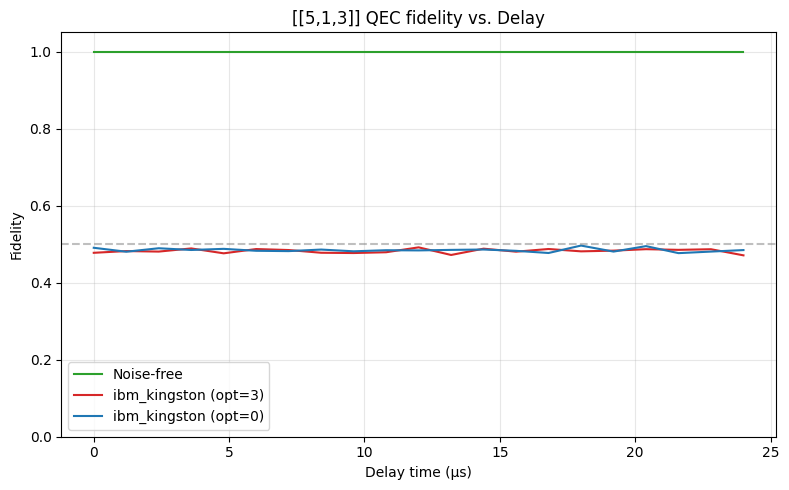

In [3]:

fig, ax = plt.subplots(figsize=(8, 5))
# Rescale tau to micro seconds for plotting
tau_ref = 1e6 * 4e-09 * tau_ref

ax.plot(tau_ref, ref["ideal_fidelities"], color="tab:green", label="Noise-free")

for i, run in enumerate(runs):
    tau = 1e6 * 4e-09 * np.array(run["tau_values"])
    opt = run.get("optimization_level", "?")
    backend = run.get("backend", "?")
    if backend != "ibm_fez":
        ax.plot(tau, run["backend_fidelities"], color=colors[i % len(colors)],label=f"{backend} (opt={opt})")

ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Delay time (µs)")
ax.set_ylabel("Fidelity")
ax.set_title("[[5,1,3]] QEC fidelity vs. Delay")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()